Dataset loaded successfully!
Shape: (8807, 12)
Cleaned data sample:


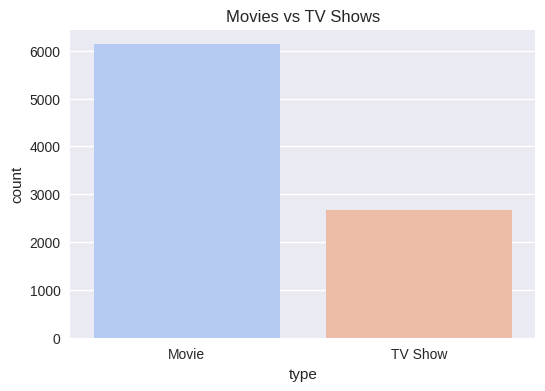

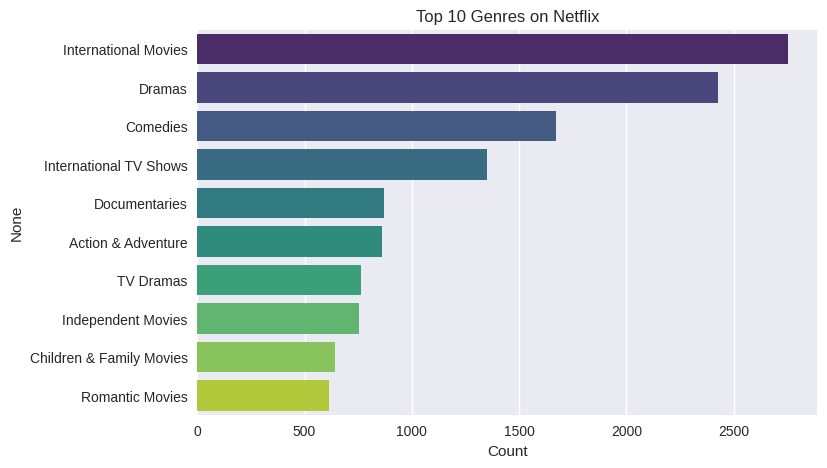

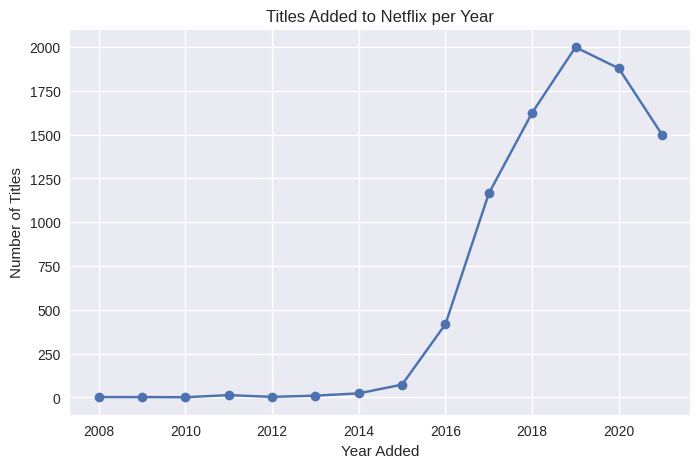

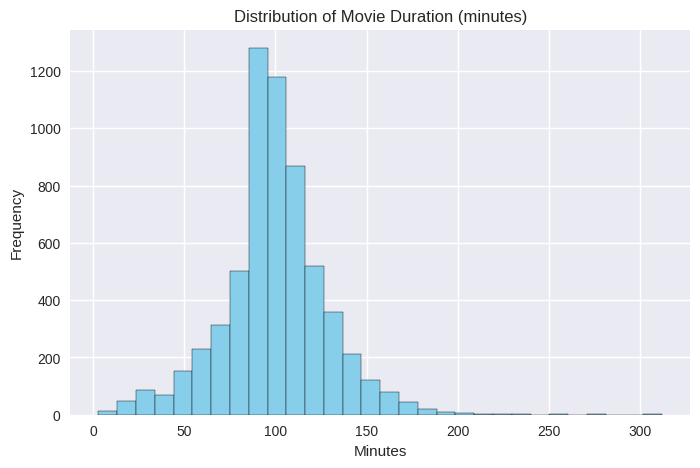

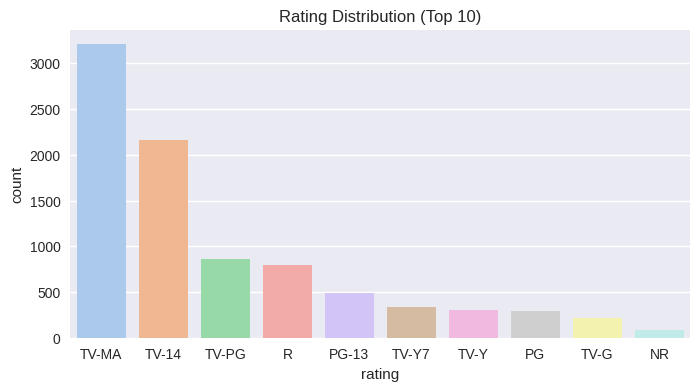

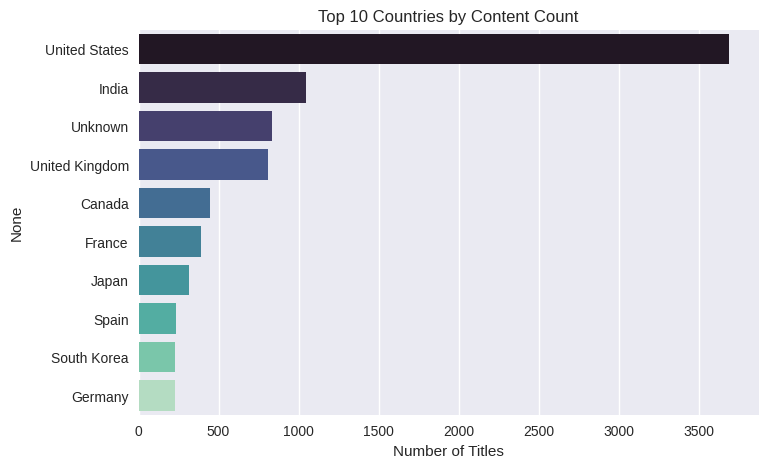


📈 Quick Insights:
- Total Titles: 8807
- Movies: 6131
- TV Shows: 2676
- Most Common Genre: International Movies
- Peak Year for Additions: 2019.0 (1999 titles added)
- Top Country: United States

Building recommender system...

🎬 Recommendations for 'Breaking Bad':

                                          title     type  release_year  \
2606                            Extracurricular  TV Show          2020   
4118                                Iron Ladies  TV Show          2018   
5352  Have You Ever Fallen in Love, Miss Jiang?  TV Show          2016   
2931                           Better Call Saul  TV Show          2018   
1067                             The Underclass  TV Show          2020   

                                              listed_in  \
2606  Crime TV Shows, International TV Shows, Korean...   
4118  International TV Shows, Romantic TV Shows, TV ...   
5352  Crime TV Shows, International TV Shows, TV Dramas   
2931             Crime TV Shows, TV Comedies, TV D

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import warnings
warnings.filterwarnings('ignore')

# For pretty plots
plt.style.use('seaborn-v0_8')

# -------------------------------
# Step 2: Load dataset
# -------------------------------
df = pd.read_csv('/content/netflix_titles[1].csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

# -------------------------------
# Step 3: Data Cleaning
# -------------------------------
# Make columns consistent
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

# Parse duration (split into number + type)
def parse_duration(x):
    if pd.isna(x): return (None, None)
    if 'min' in x:
        return (int(x.replace('min','').strip()), 'min')
    if 'Season' in x or 'Seasons' in x:
        return (int(x.split()[0]), 'season')
    return (None, None)

df[['duration_int','duration_type']] = df['duration'].apply(lambda x: pd.Series(parse_duration(x)))

# Split genres and countries into lists
df['genres'] = df['listed_in'].fillna('').apply(lambda s: [g.strip() for g in s.split(',') if g.strip()])
df['countries'] = df['country'].fillna('').apply(lambda s: [c.strip() for c in s.split(',') if c.strip()])

print("Cleaned data sample:")
df.head()

# -------------------------------
# Step 4: Exploratory Data Analysis (EDA)
# -------------------------------

# 1. Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='coolwarm')
plt.title('Movies vs TV Shows')
plt.show()

# 2. Top 10 Genres
genre_counts = Counter([g for gs in df['genres'] for g in gs])
top_genres = pd.Series(dict(genre_counts)).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.show()

# 3. Titles added per year
df['added_year'] = df['date_added'].dt.year
added_year = df['added_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))
added_year.plot(kind='line', marker='o')
plt.title('Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

# 4. Movie Duration Distribution
movies = df[df['type']=='Movie']
plt.figure(figsize=(8,5))
plt.hist(movies['duration_int'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Duration (minutes)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

# 5. Rating Distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index[:10], palette='pastel')
plt.title('Rating Distribution (Top 10)')
plt.show()

# 6. Top 10 Countries by Content Count
country_counts = Counter([c for cs in df['countries'] for c in cs])
top_countries = pd.Series(dict(country_counts)).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Number of Titles')
plt.show()

# -------------------------------
# Step 5: Insights Summary
# -------------------------------
print("\n📈 Quick Insights:")
print(f"- Total Titles: {len(df)}")
print(f"- Movies: {len(df[df['type']=='Movie'])}")
print(f"- TV Shows: {len(df[df['type']=='TV Show'])}")
print(f"- Most Common Genre: {top_genres.index[0]}")
print(f"- Peak Year for Additions: {added_year.idxmax()} ({added_year.max()} titles added)")
print(f"- Top Country: {top_countries.index[0]}")

# -------------------------------
# Step 6: Simple Content-Based Recommender
# -------------------------------
print("\nBuilding recommender system...")

# Combine text features
df['metadata'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['listed_in'].fillna('')
)

# TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=10000)
tfidf_matrix = tfidf.fit_transform(df['metadata'])

# Compute cosine similarity
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Build indices for lookup
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def get_recommendations(title, topn=5):
    if title not in indices:
        return f"'{title}' not found in dataset."
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:topn+1]
    movie_indices = [i[0] for i in sim_scores]
    return df.iloc[movie_indices][['title','type','release_year','listed_in','description']]

# Example recommendations
print("\n🎬 Recommendations for 'Breaking Bad':\n")
print(get_recommendations('Breaking Bad', 5))
